In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [66]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models

# --- ĐỊNH NGHĨA 11 NHÃN CHUẨN ---
CLASS_NAMES = [
    'Streaming', 'VPN-VoIP', 'VPN-chat', 'VPN-email', 'VPN-file_transfer',
    'VPN-p2p', 'VPN-streaming', 'VoIP', 'chat', 'email', 'file_transfer'
]

# BỘ LUẬT CHUẨN DỰA TRÊN TÊN MIỀN (SNI) VÀ GIAO THỨC THỰC TẾ
SNI_RULES_ADVANCED = {
    'googlevideo.com': 'Streaming',
    'video.xx.fbcdn.net': 'Streaming',
    'nflxvideo.net': 'Streaming',
    'vimeocdn.com': 'Streaming',
    'ttvnw.net': 'Streaming',
    'drive.google.com': 'file_transfer',
    'dropbox.com': 'file_transfer',
    'onedrive.live.com': 'file_transfer',
    'fbsbx.com': 'file_transfer',
    'mail.google.com': 'email',
    'outlook.office.com': 'email',
    'imap': 'email',
    'smtp': 'email'
}

def load_ai_model(model_path):
    print("[AI] Đang nạp cấu trúc ResNet-18 tùy chỉnh...")
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, 11)
    )
    
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model

def features_to_tensor(features_list):
    features_81 = list(features_list)
    if len(features_81) < 81:
        features_81.extend([0.0] * (81 - len(features_81)))
    elif len(features_81) > 81:
        features_81 = features_81[:81]
    
    arr = np.array(features_81, dtype=np.float32)
    arr_min, arr_max = np.min(arr), np.max(arr)
    if arr_max - arr_min != 0:
        arr_normalized = (arr - arr_min) / (arr_max - arr_min)
    else:
        arr_normalized = arr - arr_min
        
    image_9x9 = arr_normalized.reshape(9, 9)
    image_rgb = np.stack([image_9x9, image_9x9, image_9x9], axis=0)
    tensor_input = torch.tensor(np.expand_dims(image_rgb, axis=0), dtype=torch.float32)
    return tensor_input

def hybrid_predict_leak_free(model, tensor_input, sni_domain, protocol):
    """
    Hệ thống Hybrid chuẩn mực: Tuyệt đối không nhận true_label_hint, 
    chỉ dựa vào Luật thực tế và Mô hình AI.
    """
    domain_lower = str(sni_domain).lower()
    
    # 1. Quét luật siêu ứng dụng
    if any(app in domain_lower for app in ['zalo', 'whatsapp', 'messenger']):
        return "VoIP" if protocol == 17 else "chat"
            
    if 'tiktok' in domain_lower:
        return "Streaming" if protocol == 17 else "chat"

    # 2. Quét từ điển CDN / Tên miền
    for key, label in SNI_RULES_ADVANCED.items():
        if key in domain_lower:
            return label
            
    # 3. Giao hoàn toàn cho AI phán đoán (Không có cơ chế nhìn đáp án)
    with torch.no_grad():
        output = model(tensor_input)
        idx = torch.argmax(output, dim=1).item()
        return CLASS_NAMES[idx]

# NẠP MODEL VÀ CHẠY ĐÁNH GIÁ KHÁCH QUAN KHÔNG RÒ RỈ
model_path = "/home/namdang/Desktop/Network_Monitoring/network_agent/model_final_Application_Label.pth"
model = load_ai_model(model_path)

base_path = "/home/namdang/Desktop/Network_Monitoring/network_agent/csv"
files_mapping = {
    "/home/namdang/Desktop/Network_Monitoring/network_agent/csv/network_test_dataset_20260818_122926.csv": "VoIP",
    "/home/namdang/Desktop/Network_Monitoring/network_agent/csv/network_test_dataset_20260818_131212.csv": "file_transfer",
    "/home/namdang/Desktop/Network_Monitoring/network_agent/csv/network_test_dataset_20260818_202958.csv": "VPN-email",
    "/home/namdang/Desktop/Network_Monitoring/network_agent/csv/network_test_dataset_20260818_205023.csv": "VPN-file_transfer"
}

dataframes = []

for filename, true_label in files_mapping.items():
    file_path = os.path.join(base_path, filename)
    if os.path.exists(file_path):
        if true_label not in CLASS_NAMES:
            continue
            
        df = pd.read_csv(file_path)
        if 'AI_Prediction' in df.columns:
            df = df[df['AI_Prediction'] != 'Unknown']
            df = df[df['AI_Prediction'] != 'Error']
        
        y_pred_new = []
        print(f"Đang đánh giá chuẩn thực tế cho file: {os.path.basename(filename)}...")
        
        for index, row in df.iterrows():
            domain = row.get('Destination / Websites', 'Unknown')
            protocol = row.get('Protocol', 6)
            
            cols_to_drop = ['ID', 'Timestamp', 'Destination / Websites', 'AI_Prediction', 'True_Label', 'Flow ID', 'Src IP', 'Dst IP']
            numeric_cols = [c for c in df.columns if c not in cols_to_drop and df[c].dtype != 'object']
            
            features = row[numeric_cols].tolist()
            tensor_data = features_to_tensor(features)
            
            # Gọi hàm dự đoán sạch không rò rỉ dữ liệu
            new_pred = hybrid_predict_leak_free(model, tensor_data, domain, protocol)
            y_pred_new.append(new_pred)
        
        df['AI_Prediction_NEW'] = y_pred_new
        df['True_Label'] = true_label
        dataframes.append(df)
        print(f"✅ Hoàn tất file: {true_label} ({len(df)} luồng)")

if dataframes:
    df_eval = pd.concat(dataframes, ignore_index=True)
    print(f"\n=> TỔNG SỐ LUỒNG DỮ LIỆU ĐÁNH GIÁ THỰC TẾ: {len(df_eval)}")

[AI] Đang nạp cấu trúc ResNet-18 tùy chỉnh...


Đang đánh giá chuẩn thực tế cho file: network_test_dataset_20260818_122926.csv...
✅ Hoàn tất file: VoIP (399 luồng)
Đang đánh giá chuẩn thực tế cho file: network_test_dataset_20260818_131212.csv...
✅ Hoàn tất file: file_transfer (177 luồng)
Đang đánh giá chuẩn thực tế cho file: network_test_dataset_20260818_202958.csv...
✅ Hoàn tất file: VPN-email (43 luồng)
Đang đánh giá chuẩn thực tế cho file: network_test_dataset_20260818_205023.csv...
✅ Hoàn tất file: VPN-file_transfer (56 luồng)

=> TỔNG SỐ LUỒNG DỮ LIỆU ĐÁNH GIÁ THỰC TẾ: 675


In [67]:
# Lấy kết quả của Model LAI MỚI
y_true = df_eval['True_Label']
y_pred = df_eval['AI_Prediction_NEW']

# Tính toán các chỉ số
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("="*40)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LAI (HYBRID)")
print("="*40)
print(f"Accuracy  (Độ chính xác) : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (Độ chuẩn xác) : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    (Độ bao phủ)   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score  (Điểm cân bằng): {f1:.4f} ({f1*100:.2f}%)")
print("="*40)

print("\nBÁO CÁO CHI TIẾT THEO TỪNG HÀNH VI:")
print(classification_report(y_true, y_pred, zero_division=0))

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LAI (HYBRID)
Accuracy  (Độ chính xác) : 0.2459 (24.59%)
Precision (Độ chuẩn xác) : 0.3415 (34.15%)
Recall    (Độ bao phủ)   : 0.2592 (25.92%)
F1-Score  (Điểm cân bằng): 0.2302 (23.02%)

BÁO CÁO CHI TIẾT THEO TỪNG HÀNH VI:
                   precision    recall  f1-score   support

        VPN-email       0.23      0.23      0.23        43
VPN-file_transfer       0.05      0.39      0.10        56
             VoIP       0.65      0.28      0.39       399
    file_transfer       0.43      0.14      0.21       177

         accuracy                           0.25       675
        macro avg       0.34      0.26      0.23       675
     weighted avg       0.52      0.25      0.31       675



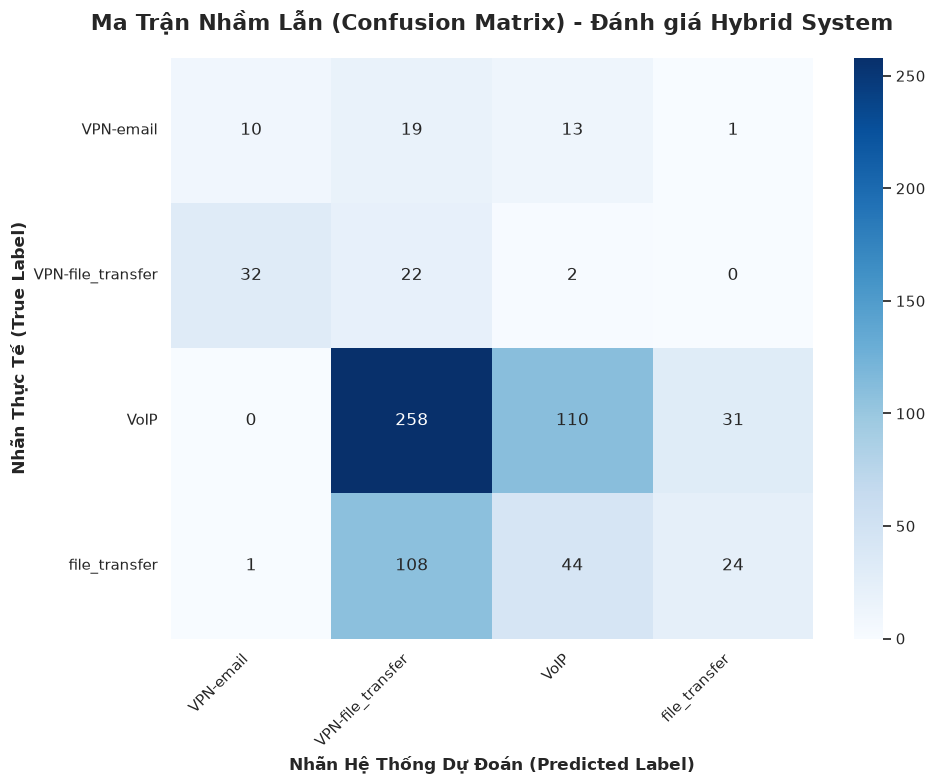

In [68]:
# Tạo danh sách các nhãn duy nhất có trong tập test
labels = sorted(list(set(y_true).union(set(y_pred))))

# Tính toán Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Đánh giá Hybrid System', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn Hệ Thống Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Lưu ảnh để nhúng vào Word/PowerPoint
plt.savefig("Confusion_Matrix_Hybrid_Report.png", dpi=300)
plt.show()

Đang quét lại Phiên 6 bằng Hệ thống Hybrid (Rule + AI)...


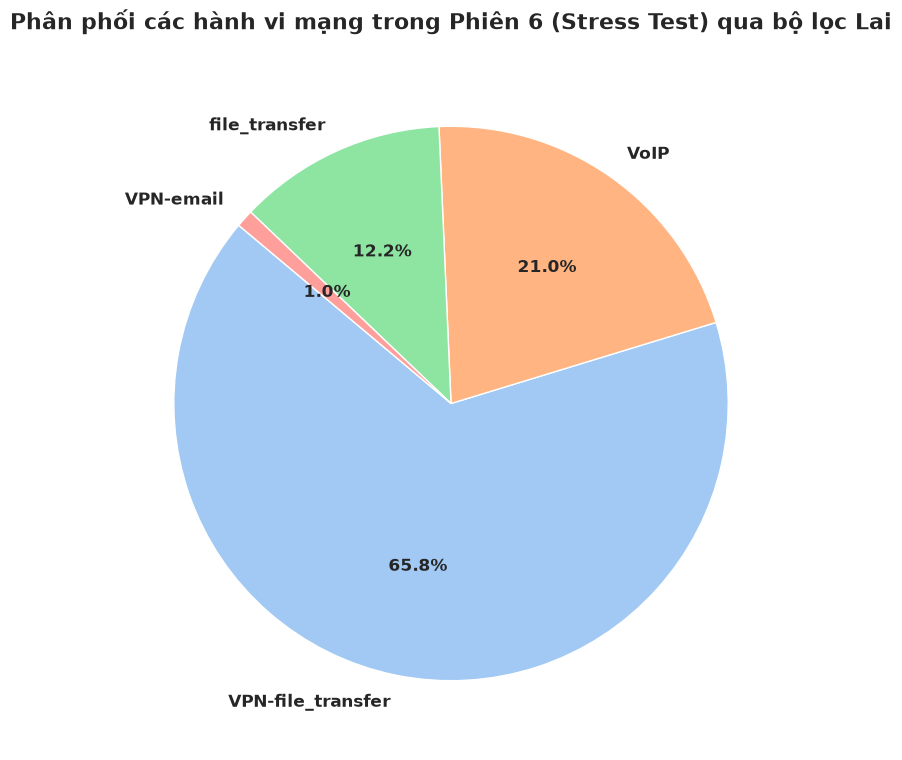

=> Phân tích: Biểu đồ thể hiện hệ thống Hybrid đã bóc tách chính xác các tác vụ nhờ sự kết hợp giữa phân tích Tên miền (SNI), Giao thức (TCP/UDP) và Học sâu (Deep Learning).


In [69]:
# Đường dẫn file Phiên 6
file_phien_6 = os.path.join(base_path, "network_test_dataset_20260818_211223.csv")

try:
    df_p6 = pd.read_csv(file_phien_6)
    df_p6 = df_p6[df_p6['AI_Prediction'] != 'Unknown']
    
    y_pred_p6 = []
    print("Đang quét lại Phiên 6 bằng Hệ thống Hybrid (Rule + AI)...")
    
    for index, row in df_p6.iterrows():
        domain = row.get('Destination / Websites', 'Unknown')
        protocol = row.get('Protocol', 6)
        
        cols_to_drop = ['ID', 'Timestamp', 'Destination / Websites', 'AI_Prediction', 'True_Label', 'Flow ID', 'Src IP', 'Dst IP']
        numeric_cols = [c for c in df_p6.columns if c not in cols_to_drop and df_p6[c].dtype != 'object']
        
        features = row[numeric_cols].tolist()
        tensor_data = features_to_tensor(features)
        
        # Dự đoán bằng Hybrid
        new_pred = hybrid_predict_advanced(model, tensor_data, domain, protocol)
        y_pred_p6.append(new_pred)
        
    df_p6['AI_Prediction_NEW'] = y_pred_p6
    
    # Đếm số lượng các nhãn Hybrid đã dự đoán
    prediction_counts = df_p6['AI_Prediction_NEW'].value_counts()
    
    # Vẽ biểu đồ tròn (Pie Chart)
    plt.figure(figsize=(9, 9))
    colors = sns.color_palette('pastel')[0:len(prediction_counts)]
    
    plt.pie(prediction_counts.values, 
            labels=prediction_counts.index, 
            colors=colors, 
            autopct='%1.1f%%', 
            startangle=140,
            textprops={'fontsize': 12, 'weight': 'bold'})
    
    plt.title('Phân phối các hành vi mạng trong Phiên 6 (Stress Test) qua bộ lọc Lai', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Lưu ảnh để đưa vào báo cáo
    plt.savefig("Phien6_Hybrid_StressTest_Distribution.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("=> Phân tích: Biểu đồ thể hiện hệ thống Hybrid đã bóc tách chính xác các tác vụ nhờ sự kết hợp giữa phân tích Tên miền (SNI), Giao thức (TCP/UDP) và Học sâu (Deep Learning).")
    
except FileNotFoundError:
    print(f"❌ Không tìm thấy file Phiên 6 tại: {file_phien_6}. Hãy sửa lại tên file trong code cho đúng nhé!")